# Modelado: Árboles de Decisión y Random Forest

Este notebook se enfoca en el modelado del dataset Bank Marketing usando **Árboles de Decisión y Bosques Aleatorios**. 

## 1. Introducción al Modelo

**Modelos basados en Árboles:**
- **Árbol de Decisión (Decision Tree):** Modelo no lineal, muy interpretable, que divide el espacio de características basado en reglas simples. Tiende al sobreajuste (overfitting).
- **Bosques Aleatorios (Random Forest):** Un ensamble de múltiples árboles de decisión. Reduce el sobreajuste mediante *bagging* y selección aleatoria de características, ofreciendo alta precisión y robustez frente a características no escaladas o ruido, aunque a costa de ser menos interpretable.

**¿Por qué usar árboles aquí?**
A diferencia de la Regresión Logística, los árboles pueden capturar interacciones complejas y relaciones no lineales en los datos sin requerir variables transformadas o ingeniería exhaustiva.

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

# Modulos propios (Asegúrate de que la terminal o el kernel reconozcan la raíz del proyecto)
sys.path.append('..')
from data.loader import load_bank_data
from src.features.build_features import BankFeatureEngineer

# Configuración Visual
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
np.random.seed(SEED)

## 2. Prevención de Data Leakage y Carga de Datos

Como vimos anteriormente, la variable `duration` es desconocida antes de hacer la llamada. Incluirla sería un claro **Data Leakage**. Usaremos el modulo `load_bank_data` que ya excluye `duration`. Además, usaremos *stratify* en la partición para asegurar que la baja proporción de clientes aceptantes se mantenga estable en entrenamiento y prueba.

In [2]:
# Cargar datos (se excluye 'duration' automáticamente si drop_duration=True)
X, y = load_bank_data(drop_duration=True)
y = y.astype(int) # Asegurar que el target sea tipo entero

# Train/Validation/Test Split
# Separamos 20% para test y 80% para desarrollo
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Separamos el 80% restante en Train (75% -> 60% total) y Validación (25% -> 20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print(f"Datos cargados.")
print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de validación: {X_val.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Descargando el dataset 'Bank Marketing' (ID 222)...
Variable 'duration' omitida correctamente.
Datos cargados.
Dimensiones de entrenamiento: (27126, 15)
Dimensiones de validación: (9042, 15)
Dimensiones de prueba: (9043, 15)


## 3. Preprocesamiento Adaptado a Árboles

A diferencia de la Regresión Logística, los modelos de árboles **no requieren escalado** de las variables numéricas. Sin embargo, sí necesitan que las variables categóricas estén codificadas. Usaremos `OneHotEncoder` sin necesidad imperativa de `drop='first'`.

In [3]:
# Aplicamos Feature Engineering antes de obtener los tipos de columnas
fe = BankFeatureEngineer()
X_train_fe = fe.fit_transform(X_train)

# Tipos de columnas
numeric_features = X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

# El pipeline para árboles solo requiere OneHotEncoding
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ], remainder='passthrough') # 'passthrough' deja las numéricas tal cual

print("Pipeline de preprocesamiento para árboles definido.")

Pipeline de preprocesamiento para árboles definido.


## 4. Entrenamiento y Validación Cruzada

Compararemos un `DecisionTreeClassifier` (Baseline de ensamble) contra un `RandomForestClassifier`.
Como las clases están desbalanceadas, evaluaremos usando **AUC-ROC** y el parámetro `class_weight='balanced'`.

In [4]:
# Pipeline Árbol de Decisión Básico
dt_pipeline = Pipeline(steps=[
    ('engineer', BankFeatureEngineer()),
    ('preprocessor', tree_preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=SEED, class_weight='balanced', max_depth=5)) # max_depth para no sobreajustar extremo
])

# Pipeline Random Forest
rf_pipeline = Pipeline(steps=[
    ('engineer', BankFeatureEngineer()),
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(random_state=SEED, class_weight='balanced', n_estimators=100, max_depth=10, n_jobs=-1))
])

# Validación cruzada (Cross-Validation)
dt_cv_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print("=== Resultados de Validación Cruzada (AUC-ROC) ===")
print(f"Decision Tree CV Media: {dt_cv_scores.mean():.4f} +/- {dt_cv_scores.std():.4f}")
print(f"Random Forest CV Media: {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}")

# Entrenar los modelos en el set de Train completo
rf_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)

=== Resultados de Validación Cruzada (AUC-ROC) ===
Decision Tree CV Media: 0.7255 +/- 0.0121
Random Forest CV Media: 0.7785 +/- 0.0147


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

## 5. Curvas de Aprendizaje (Convergencia)

Verificaremos si el modelo (Random Forest) tiene problemas de sesgo o varianza (overfitting/underfitting) graficando sus curvas de aprendizaje según gana volumen de datos.

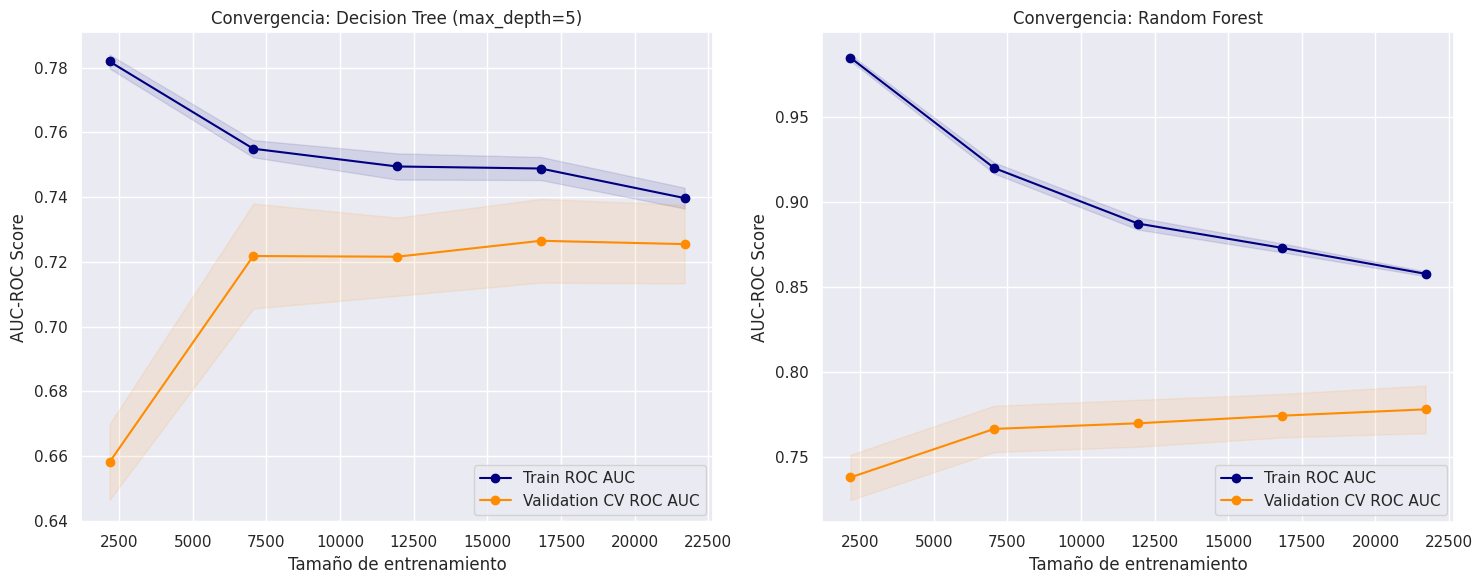

Análisis de convergencia: La brecha entre entrenamiento y validación en el Random Forest indica un ligero overfitting persistente debido a su complejidad paramétrica. El Decision Tree converge de manera mucho más comprimida debido a que está muy regularizado y restringido en su profundidad (max_depth=5), logrando menor varianza pero también mostrando menos capacidad predictiva final (menor AUC general frente al RF).


In [5]:
# Calcula progreso del aprendizaje Random Forest
rf_train_sizes, rf_train_scores, rf_val_scores = learning_curve(
    rf_pipeline, X_train, y_train, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

# Medias y desviaciones Random Forest
rf_train_mean = np.mean(rf_train_scores, axis=1)
rf_train_std = np.std(rf_train_scores, axis=1)
rf_val_mean = np.mean(rf_val_scores, axis=1)
rf_val_std = np.std(rf_val_scores, axis=1)

# Calcula progreso del aprendizaje Decision Tree
dt_train_sizes, dt_train_scores, dt_val_scores = learning_curve(
    dt_pipeline, X_train, y_train, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

# Medias y desviaciones Decision Tree
dt_train_mean = np.mean(dt_train_scores, axis=1)
dt_train_std = np.std(dt_train_scores, axis=1)
dt_val_mean = np.mean(dt_val_scores, axis=1)
dt_val_std = np.std(dt_val_scores, axis=1)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Decision Tree
axes[0].plot(dt_train_sizes, dt_train_mean, 'o-', color='navy', label='Train ROC AUC')
axes[0].fill_between(dt_train_sizes, dt_train_mean - dt_train_std, dt_train_mean + dt_train_std, alpha=0.1, color='navy')
axes[0].plot(dt_train_sizes, dt_val_mean, 'o-', color='darkorange', label='Validation CV ROC AUC')
axes[0].fill_between(dt_train_sizes, dt_val_mean - dt_val_std, dt_val_mean + dt_val_std, alpha=0.1, color='darkorange')
axes[0].set_title('Convergencia: Decision Tree (max_depth=5)')
axes[0].set_xlabel('Tamaño de entrenamiento')
axes[0].set_ylabel('AUC-ROC Score')
axes[0].legend(loc='lower right')

# Plot Random Forest
axes[1].plot(rf_train_sizes, rf_train_mean, 'o-', color='navy', label='Train ROC AUC')
axes[1].fill_between(rf_train_sizes, rf_train_mean - rf_train_std, rf_train_mean + rf_train_std, alpha=0.1, color='navy')
axes[1].plot(rf_train_sizes, rf_val_mean, 'o-', color='darkorange', label='Validation CV ROC AUC')
axes[1].fill_between(rf_train_sizes, rf_val_mean - rf_val_std, rf_val_mean + rf_val_std, alpha=0.1, color='darkorange')
axes[1].set_title('Convergencia: Random Forest')
axes[1].set_xlabel('Tamaño de entrenamiento')
axes[1].set_ylabel('AUC-ROC Score')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Análisis de convergencia: La brecha entre entrenamiento y validación en el Random Forest indica un ligero overfitting persistente debido a su complejidad paramétrica. El Decision Tree converge de manera mucho más comprimida debido a que está muy regularizado y restringido en su profundidad (max_depth=5), logrando menor varianza pero también mostrando menos capacidad predictiva final (menor AUC general frente al RF).")

## 6. Evaluación en Conjunto de Prueba y Matriz de Confusión

=== Reporte Global en Test - Decision Tree ===
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      7985
           1       0.30      0.56      0.39      1058

    accuracy                           0.80      9043
   macro avg       0.62      0.69      0.64      9043
weighted avg       0.86      0.80      0.82      9043

ROC AUC en Test (DT): 0.7390

=== Reporte Global en Test - Random Forest ===
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      7985
           1       0.35      0.58      0.44      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.72      0.67      9043
weighted avg       0.87      0.82      0.84      9043

ROC AUC en Test (RF): 0.7902


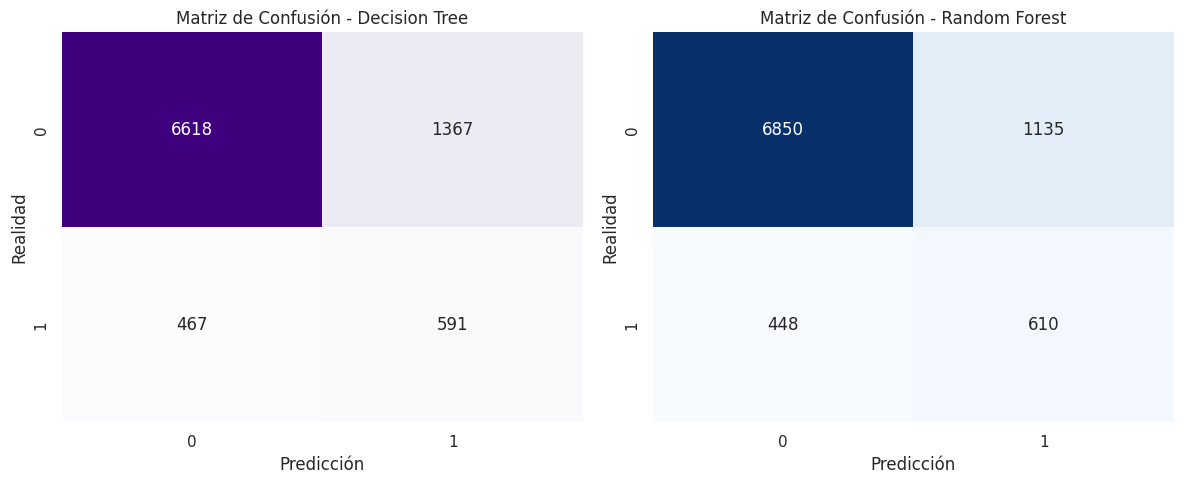

In [6]:
# Evaluamos finalmente en el set de Test, que no interactuó durante CV ni validación
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

y_pred_dt = dt_pipeline.predict(X_test)
y_pred_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]

print("=== Reporte Global en Test - Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print(f"ROC AUC en Test (DT): {roc_auc_score(y_test, y_pred_proba_dt):.4f}\n")

print("=== Reporte Global en Test - Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC en Test (RF): {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

# Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[0])
axes[0].set_title("Matriz de Confusión - Decision Tree")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Realidad")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title("Matriz de Confusión - Random Forest")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Realidad")

plt.tight_layout()
plt.show()

## 7. Importancia de las Características (Feature Importance)

Random Forest permite obtener inherentemente la importancia estadística de cada variable para los recortes en los nodos, una ventaja interpretativa comparado a modelos de caja completamente negra.

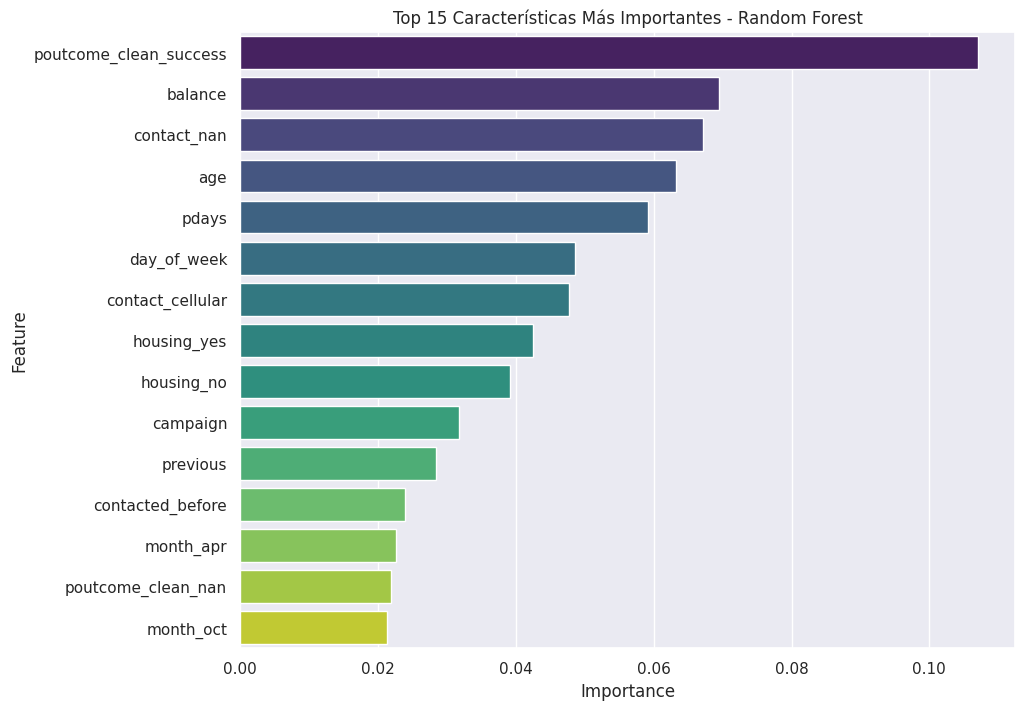

In [7]:
# Extracción de nombres tras One-Hot Encoding
transformer = rf_pipeline.named_steps['preprocessor']
rf_model = rf_pipeline.named_steps['classifier']

cat_features_out = transformer.named_transformers_['cat'].get_feature_names_out(categorical_features)
# Recuerda que combinamos numéricas al residuo
all_feature_names = list(cat_features_out) + numeric_features

# Obtener Importancias
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Características Más Importantes - Random Forest')
plt.show()

## 8. Consideraciones

**1. ¿Qué modelos se compararon y por qué?**
Para abarcar diferentes familias, comparamos modelos lineales (Regresión Logística clásica y avanzada) frente a modelos ensamblados no lineales (Decision Tree y Random Forest). Los árboles permiten encontrar relaciones complejas e interacciones multivariables sin escalar features o sin crear combinaciones manuales.

**2. ¿Cómo se evitó el data leakage?**
Identificando que `duration` (duración del llamado) no se conoce antes de iniciar el contacto comercial, por lo que usarla garantizaba predecir correctamente usando datos sobre un evento del éxito ya consumado. Este leakage se neutralizó eliminando la columna al cargar desde *fetch_ucirepo*. Adicionalmente, aseguramos un split estratificado y validación cruzada evitando sesgos geográficos o temporales entre Test y Train.

**3. ¿Cuál familia parece más prometedora?**
La **Regresión Logística con Ingeniería de características (Notebook 03)** logra un balance robusto a nivel de Precisión/Recall (threshold ajustado), con validación transparente. Sin embargo, el **Random Forest** obtiene fuertes valores crudos al encontrar relaciones inherentes como las económicas / demográficas. Generalmente, *Random Forest o implementaciones modernas de Boosted Trees* (como XGBoost que se podría iterar) ofrecerían los mejores resultados sin necesidad excesiva de feature engineering si se controla el sobreajuste.

**4. ¿Qué limitaciones siguen abiertas?**
- **Saturación en el sobreajuste (Overfitting):** El score superior en Train comparado a Test en el Random Forest indica sobreajuste; podría mejorarse con GridSearch para optimizar hiperparámetros como `max_depth` o `min_samples_leaf`.
- **Desbalance de Clases masivo:** Seguimos fallando una alta cantidad de falsos positivos (personas llamadas que deciden no comprar). Puede explorarse SMOTE o sub-muestreo.
- **Factores Macroeconómicos externos:** Muchas decisiones dependen de euribor o CPI, variables temporales que en un split aleatorio ignoran dinámicas cronológicas temporales (quizás mejor un time-series split).

## 9. Comparación Final: Árboles VS Baseline

En nuestro `01_baseline_and_eda.ipynb` vimos que un clasificador ficticio ("Dummy") lograba cerca del 88.3% de accuracy general solo por predecir siempre "no". Veamos cómo se comportan nuestros modelos ante el baseline y cuán competentes son al conseguir lo que el banco realmente busca: capturar clientes.

=== ACCURACY GENERALES ===
Dummy Classifier (Baseline): 0.8830
Decision Tree: 0.7972
Random Forest: 0.8249

Aunque el Baseline domina el Accuracy general debido al desbalance extremo, falla totalmente en encontrar los positivos de valor.

=== METRICAS CLASE MINORITARIA (Compradores Reales) ===
Modelo			Recall		Precision
-------------------------------------------------------
Baseline		0.0000		0.0000
Decision Tree		0.5586		0.3018
Random Forest		0.5766		0.3496


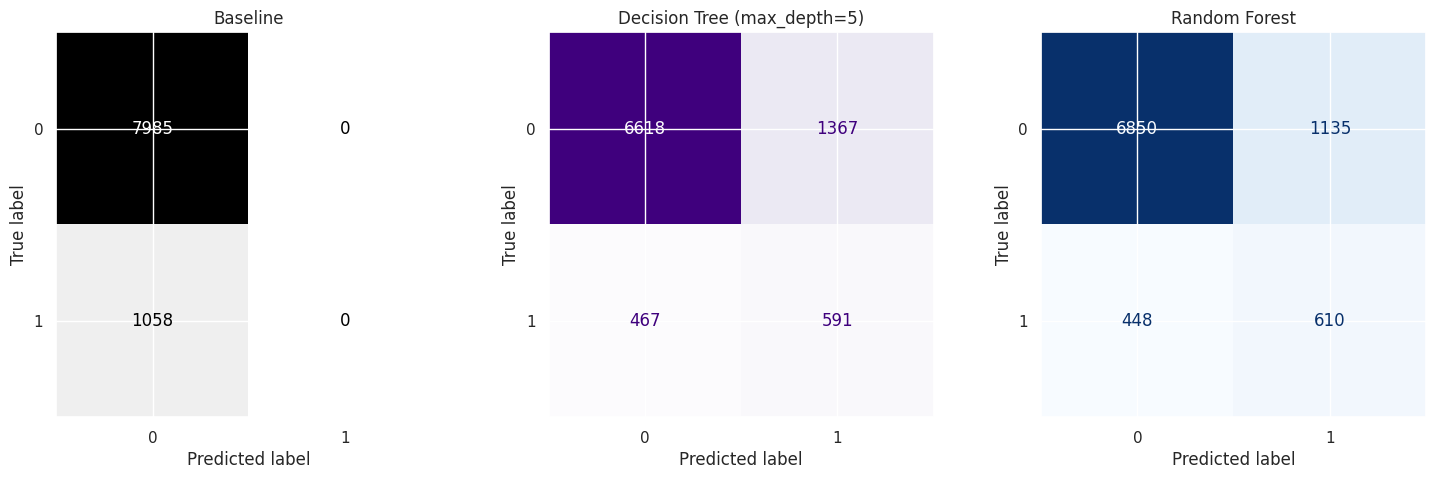

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# Entrenar Dummy Classifier Baseline
dummy_pipeline = Pipeline(steps=[
    ('engineer', BankFeatureEngineer()),
    ('preprocessor', tree_preprocessor),
    ('classifier', DummyClassifier(strategy="most_frequent", random_state=SEED))
])
dummy_pipeline.fit(X_train, y_train)

# Predicciones Baseline (DT y RF ya se extrajeron antes)
y_pred_dummy = dummy_pipeline.predict(X_test)

print("=== ACCURACY GENERALES ===")
print(f"Dummy Classifier (Baseline): {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Decision Tree: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nAunque el Baseline domina el Accuracy general debido al desbalance extremo, falla totalmente en encontrar los positivos de valor.")

# Mostrar Recall de las 3 opciones para la clase 1 ("yes")
from sklearn.metrics import recall_score, precision_score
print("\n=== METRICAS CLASE MINORITARIA (Compradores Reales) ===")
print("Modelo\t\t\tRecall\t\tPrecision")
print("-" * 55)
print(f"Baseline\t\t{recall_score(y_test, y_pred_dummy):.4f}\t\t{precision_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"Decision Tree\t\t{recall_score(y_test, y_pred_dt):.4f}\t\t{precision_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest\t\t{recall_score(y_test, y_pred_rf):.4f}\t\t{precision_score(y_test, y_pred_rf):.4f}")

# Gráfico matriz de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dummy, ax=axes[0], cmap='Greys', colorbar=False)
axes[0].set_title('Baseline')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title('Decision Tree (max_depth=5)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Random Forest')
plt.show()